# TP4 Fonctions prédictives 

Membres de l'équipe : 
- Titouan CHOALER chot4078
- Ethan BROUILLET broe5997

## 1. Implémentation de fonctions

### a)

In [8]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

def model_score(X, y, class_model=KNeighborsClassifier, params={}):
    model = class_model(**params)
    scores = cross_val_score(model, X, y, cv=5)
    return np.mean(scores)

### b)

In [9]:
def bruteforce_optimisation(class_model, grille_param, X, y): 
    max_score = 0
    max_params = {}
    for param in grille_param['n_neighbors']:
        for param2 in grille_param['p']:
            score = model_score(X, y, class_model, {'n_neighbors': param, 'p': param2})
            if score > max_score:
                max_score = score
                max_params = {'n_neighbors': param, 'p': param2}
    return max_params

### c)

In [10]:
import random
import itertools

def randomize_optimisation(class_model, grille_param, X, y, sample_percent):
    combo = list(itertools.product(grille_param['n_neighbors'], grille_param['p']))
    nb_iter = int(len(combo) * (sample_percent / 100))
    randomized_combo = random.sample(combo, nb_iter)
    max_score = 0
    max_params = {}
    for param , param2 in randomized_combo:
        score = model_score(X, y, class_model, {'n_neighbors': param, 'p': param2})
        if score > max_score:
            max_score = score
            max_params = {'n_neighbors': param, 'p': param2}
    return max_params

### d)

In [11]:
def halving_optimisation(class_model, grille_param, X, y, n_splitting):
    combo = list(itertools.product(grille_param['n_neighbors'], grille_param['p']))
    nb_combos = len(combo)
    nb_data = len(X)
    for i in range(1, n_splitting + 1):
        nb_keep = int(nb_data * (i / n_splitting))
        X_keep = X[:nb_keep]
        y_keep = y[:nb_keep]
        score_keep = []
        for param , param2 in combo:
            score = model_score(X_keep, y_keep, class_model, {'n_neighbors': param, 'p': param2})
            score_keep.append((score, (param, param2)))
        score_keep.sort(key=lambda x: x[0], reverse=True)
        nb_score_keep = int(nb_combos * (n_splitting - i) / n_splitting)
        if nb_score_keep == 0 :
            nb_score_keep = 1
        combo = [item[1] for item in score_keep[:nb_score_keep]]
    best_params = {'n_neighbors': combo[0][0], 'p': combo[0][1]}
    return best_params

### e)

In [12]:
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm

def bayesian_optimisation(class_model, grille_param, X, y, s_size, n_iter):
    combo = list(itertools.product(grille_param['n_neighbors'], grille_param['p']))
    E = random.sample(combo, s_size)
    E_score = []
    for param , param2 in E:
        score = model_score(X, y, class_model, {'n_neighbors': param, 'p': param2})
        E_score.append(score)
    gpr = GaussianProcessRegressor()
    gpr.fit(E, E_score)
    for i in range(n_iter):
        mean, std = gpr.predict(combo, return_std=True)
        max_pred_mean = np.max(mean)
        sampled = random.sample(combo, s_size)
        mean_sampled, std_sampled = gpr.predict(sampled, return_std=True)
        proba = norm.cdf((mean_sampled - max_pred_mean) / (std_sampled + 10**-6))
        max_param = sampled[np.argmax(proba)]
        score = model_score(X, y, class_model, {'n_neighbors': max_param[0], 'p': max_param[1]})
        E.append(max_param)
        E_score.append(score)
        gpr.fit(E, E_score)
    best_param = E[np.argmax(E_score)]
    return {'n_neighbors': best_param[0], 'p': best_param[1]}

## 2. Comparaison de fonctions

### a)

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = pd.read_csv('TP4-data.csv')
y = X['Classe']
X = X.drop(columns=['Classe'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### b)

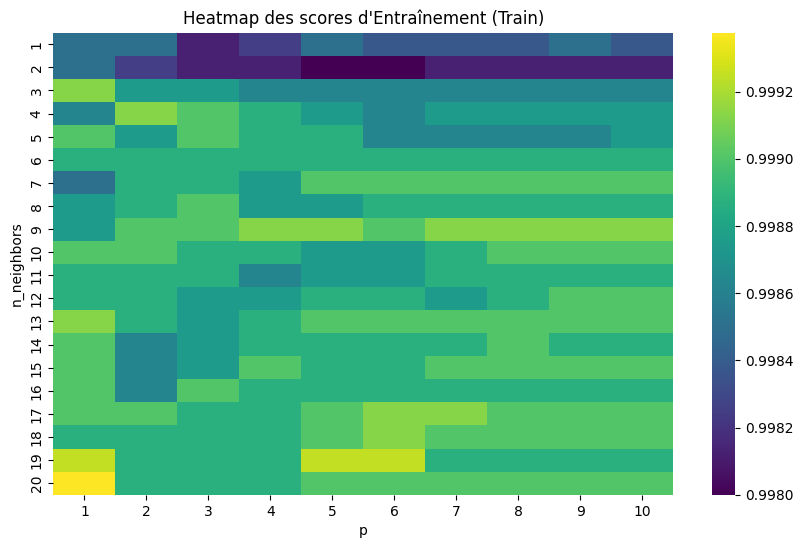

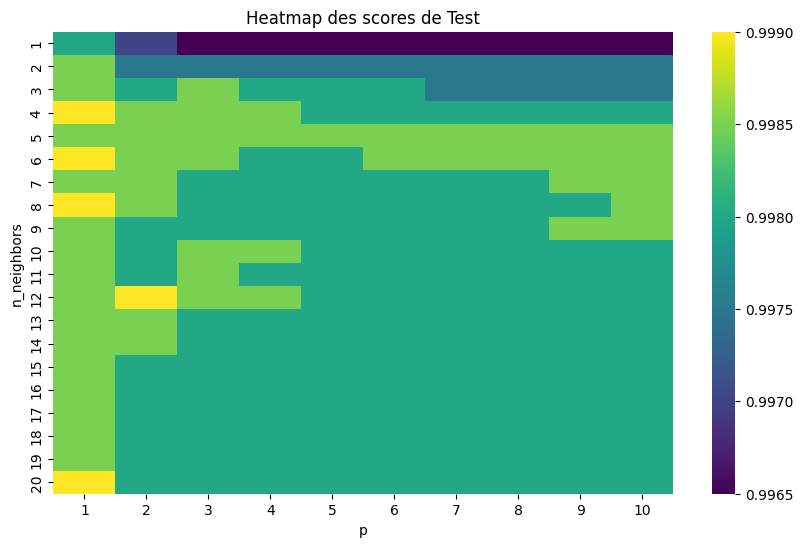

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_neighbors_list = [i for i in range(1, 21)]
p_list = [i for i in range(1, 11)]

results = []

for n_neighbors in n_neighbors_list:
    for p in p_list:
        score_train = model_score(X_train, y_train, KNeighborsClassifier, {'n_neighbors': n_neighbors, 'p': p})
        modele = KNeighborsClassifier(n_neighbors=n_neighbors, p=p)
        modele.fit(X_train, y_train)
        score_test = modele.score(X_test, y_test)
        results.append({
            'n_neighbors': n_neighbors,
            'p': p,
            'score_train': score_train,
            'score_test': score_test
        })

df_resultats = pd.DataFrame(results) 
grille_train = df_resultats.pivot(index='n_neighbors', columns='p', values='score_train')
grille_test = df_resultats.pivot(index='n_neighbors', columns='p', values='score_test')

plt.figure(figsize=(10, 6))
sns.heatmap(grille_train, cmap='viridis', annot=False) 
plt.title("Heatmap des scores d'Entraînement (Train)")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(grille_test, cmap='viridis', annot=False)
plt.title("Heatmap des scores de Test")
plt.show()

### c)

In [37]:
from sklearn import model_selection
from sklearn.experimental import enable_halving_search_cv
from skopt import gp_minimize
from skopt.space import Integer
from skopt.utils import use_named_args

best_params1 = bruteforce_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train)
print(" Brute force : ", best_params1)
best_params2 = randomize_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, 30)
print(" Randomized : ", best_params2)
best_params3 = halving_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, 5)
print(" Halving : ", best_params3)
best_params4 = bayesian_optimisation(KNeighborsClassifier, {'n_neighbors': n_neighbors_list, 'p': p_list}, X_train, y_train, 5, 100)
print(" Bayesian : ", best_params4)

print("================================================")

best_params_acc1 = model_selection.GridSearchCV(KNeighborsClassifier(), {'n_neighbors': n_neighbors_list, 'p': p_list}, scoring='accuracy')
best_params_acc1.fit(X_train, y_train)
print(" Grid search : ", best_params_acc1.best_params_)
best_params_acc2 = model_selection.RandomizedSearchCV(KNeighborsClassifier(), {'n_neighbors': n_neighbors_list, 'p': p_list}, n_iter=60, scoring='accuracy')
best_params_acc2.fit(X_train, y_train)
print(" Randomized search : ", best_params_acc2.best_params_)
best_params_acc3 = model_selection.HalvingGridSearchCV(KNeighborsClassifier(), {'n_neighbors': n_neighbors_list, 'p': p_list}, factor=5, scoring='accuracy')
best_params_acc3.fit(X_train, y_train)
print(" Halving search : ", best_params_acc3.best_params_)

domain = [Integer(1, 20, name='n_neighbors'), Integer(1, 10, name='p')]

@use_named_args(domain)
def one_minus_score(**params):
    score = model_score(X_train, y_train, KNeighborsClassifier, params)
    return 1 - score

results = gp_minimize(one_minus_score, domain)
best_params_acc4 = {'n_neighbors': results.x[0], 'p': results.x[1]}
print(" Bayesian search : ", best_params_acc4)

 Brute force :  {'n_neighbors': 20, 'p': 1}
 Randomized :  {'n_neighbors': 20, 'p': 1}
 Halving :  {'n_neighbors': 20, 'p': 1}
 Bayesian :  {'n_neighbors': 4, 'p': 2}
 Grid search :  {'n_neighbors': 20, 'p': 1}
 Randomized search :  {'p': 1, 'n_neighbors': 19}
 Halving search :  {'n_neighbors': 9, 'p': 1}


/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), np.int64(1)] before, using random point [np.int64(20), np.int64(8)]
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), np.int64(1)] before, using random point [np.int64(15), np.int64(4)]
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(17), np.int64(6)] before, using random point [np.int64(12), np.int64(3)]
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), np.int64(1)] before, using random point [np.int64(17), np.int64(8)]
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/skopt/optimizer/optimize

 Bayesian search :  {'n_neighbors': np.int64(20), 'p': np.int64(1)}


Lorsque l'on execute les huit fonctions pour trouver les meilleurs hyperparamètres  sur le modèle KNeighborsClassifier on obtient :

- les méthodes de recherche exhaustive (bruteforce_optimisation et model_selection.GridSearchCV) ont toutes les deux convergé vers n_neighbors = 20 et p = 1. Ces deux algorithmes testent l'intégralité des 200 combinaisons possibles de la grille. Qu'on obtienne exactement le même résultat valide l'exactitude de notre implémentation par rapport à celle de scikit-learn. Le paramétrage (20, 1) représente l'optimum global absolu sur nos données d'entraînement. On va comparer avec ce que les autres méthodes obtiennent parce que ces deux méthodes sont gourmandes opéarations computationnelles.

- les méthodes d'échantillonnage aléatoire (randomize_optimisation et model_selection.RandomizedSearchCV). On obtient n_neighbors = 20, p = 1 avec le premier et n_neighbors = 19, p = 1 avec le deuxième. Ces algorithmes n'explorent qu'une partie de l'espace de recherche (60 combinaisons sur 200) et ce de façon aléatoire, ce qui fait que si on relance l'execution les resultats change. La version de scikit-learn n'a très probablement pas tiré la combinaison (20, 1) lors de ses 60 itérations, et s'est arrêtée sur (19, 1). Mathématiquement. Avec ces algorithmes on réduit le nombre de calculs mais avec si peux de combinaisons on a de forte chance de ne pas tomber sur les bons resultats.

- les méthodes d'élimination successive (halving_optimisation et model_selection.HalvingGridSearchCV). Pour halving_optimisation (avec s_splitting = 5) on a n_neighbors = 20, p = 1, alors qu'avec model_selection.HalvingGridSearchCV (avec factor = 5) on obtient n_neighbors = 9, p = 1. Le résultat (9, 1) obtenu par scikit-learn montre un problème qui fait que sur les tous premiers sous-échantillons avec peu de données, la configuration k=9 a du obtenir un score temporairement supérieur à k=20. L'optimum global a donc été éliminé prématurément avant de pouvoir être testé sur 100% des données.

- l'optimisation Bayésienne (bayesian_optimisation skopt.gp_minimize). On obtient comme meilleur param n_neighbors = 4, p = 2 pour notre version et avec skopt.gp_minimize on a n_neighbors = 20, p = 1 comme optimum global. Notre implémentation a probablement tiré des échantillons initiaux très performants dans la région de k=4 et p=2, et a privilégié "l'exploitation" de cette zone (qui offre un score local excellent) au détriment de "l'exploration" vers des valeurs de k plus élevées. La version skopt, plus robuste, a réussi à contourner ce minimum local pour retrouver la  solution globale.

Donc pour la distance (p), la forte récurrence de p = 1 laisse supposer que la distance de Manhattan sépare beaucoup plus efficacement les 20 classes de ce jeu de données que la distance Euclidienne. Pour le voisinage (k), les optimums convergent vers une valeur élevée (k = 19 ou 20), ce qui indique qu'il faudra un voisinage large pour lisser le bruit et construire des zones de classification robustes.

### d)